In [20]:
!git clone --single-branch --branch noise_aware-passes https://github.com/poig/ucc.git

Cloning into 'ucc'...
remote: Enumerating objects: 4603, done.
remote: Counting objects: 100% (1588/1588), done.
remote: Compressing objects: 100% (594/594), done.
remote: Total 4603 (delta 1279), reused 1031 (delta 992), pack-reused 3015 (from 3)
Receiving objects: 100% (4603/4603), 52.79 MiB | 43.77 MiB/s, done.
Resolving deltas: 100% (2640/2640), done.


In [19]:
# !rm -rf ucc

In [3]:
from google.colab import drive

drive.mount("/content/drive")
!pip install -q qiskit qiskit_ibm_runtime
# !cd ucc && uv sync --all-extras --all-groups -q

Mounted at /content/drive


In [2]:
# python /content/ucc/ucc/noise_aware/ml_model/generate_dataset.py ^
# --num-samples 10_000 ^
# --max-qubits 20 ^
# --min-qubits 4 ^
# --output-file /content/ucc/ucc/noise_aware/ml_model/diverse_fidelity_dataset.json ^
# --max-seq-len 1024


!python /content/ucc/ucc/noise_aware/collab_create.py --num-samples 10_000 --max-qubits 20 --min-qubits 4 --output-file /content/ucc/ucc/noise_aware/ml_model/10k_dataset.json --max-seq-len 1024

--- Initializing Backend and Noise Models ---
Initialized with backend: fake_washington (127 qubits)
Feature vector dimension is set to: 16

--- Generating 10000 Data Samples from Diverse Portfolio ---
Generating Circuits: 100% 10000/10000 [37:50<00:00,  4.40it/s]

--- Dataset Generation Complete ---
Successfully created 7940 samples.
Saved to '/content/ucc/ucc/noise_aware/ml_model/10k_dataset.json'

Dataset Composition:
- qcnn: 1497 samples (18.9%)
- qft: 2550 samples (32.1%)
- qv: 386 samples (4.9%)
- EfficientSU2: 2522 samples (31.8%)
- random: 985 samples (12.4%)


In [5]:
# python /content/ucc/ucc/noise_aware/ml_model/train_model.py ^
#     --dataset-path /content/ucc/ucc/noise_aware/ml_model/10k_sample_dataset.json ^
#     --output-dir /content/ucc/ucc/noise_aware/ml_model/model/trained_models_20q/ ^
#     --epochs 50 ^
#     --batch-size 64 ^
#     --learning-rate 0.0001 ^
#     --patience 7 ^
#     --min-delta 0.000005 ^
#     --model-dim 256 ^
#     --n-heads 8 ^
#     --n-layers 8 ^
#     --max-seq-len 1024

!python /content/ucc/ucc/noise_aware/ml_model/train_model.py --dataset-path /content/ucc/ucc/noise_aware/ml_model/10k_dataset.json --output-dir /content/ucc/ucc/noise_aware/ml_model/model/trained_models_20q/ --epochs 50 --batch-size 64 --learning-rate 0.0001 --patience 7 --min-delta 0.000005 --model-dim 256 --n-heads 8 --n-layers 8 --max-seq-len 1024

--- Using device: cpu ---
Loading dataset from: /content/ucc/ucc/noise_aware/ml_model/10k_dataset.json
Loaded 7940 samples. Training on 6352, validating on 1588.
/content/ucc/ucc/noise_aware/ml_model/train_model.py:289: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(

--- Starting Model Training ---
Epoch 1/50 [Training]:   0% 0/100 [00:00<?, ?it/s]^C


In [ ]:
# !pip install colab-xterm
# %load_ext colabxterm
# %xterm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.6/115.6 kB 4.9 MB/s eta 0:00:00


In [ ]:
# https://medium.com/@wl8380/how-to-mount-google-drive-in-google-colab-c688ec8eccb7
# import h5py
# from PIL import Image
# import numpy
#
# fileName = 'data.h5'
# with h5py.File(fileName, "a") as out:
#    img = Image.open("X_train_1.jpg")      # X_train_1.jpg is 256 x 256 RGB image
#    out['X_train'] = numpy.asarray(img)

# now run test

In [ ]:
# --- Setup: Import necessary libraries ---
import torch
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import os

from qiskit.visualization import plot_error_map
from qiskit import QuantumCircuit, transpile
from qiskit.transpiler import PassManager, Layout
from qiskit.circuit.library import QFT
from qiskit.transpiler.passes import SabreLayout, BasisTranslator
from qiskit.circuit.equivalence_library import StandardEquivalenceLibrary
from qiskit_ibm_runtime.fake_provider import (
    FakeWashingtonV2,
)  # Using a large, complex backend

# Import all your custom UCC components
# Make sure these files are in the correct path relative to your notebook
# or that your project is installed in the environment.
from ucc import compile as ucc_compile_original
from ucc.noise_aware import (
    DeviceNoiseProfile,
    MLFidelityRouter,
    CircuitFormer,
)  # Assuming model is in this path
from ucc.noise_aware.backend_utils import get_target

# --- PART 1: LOAD THE TRAINED AI MODEL ---
print("--- Loading AI Model ---")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define model parameters to match the trained model
model_params = {
    "feature_dim": 16,
    "model_dim": 64,
    "n_heads": 4,
    "n_layers": 4,
    "dropout": 0.1,
    "max_seq_len": 256,
}
MAX_SEQ_LEN_CONFIG = 256

# Instantiate the model architecture
trained_model = CircuitFormer(**model_params).to(device)

# --- IMPORTANT: UPDATE THIS PATH ---
# Use an absolute path or a path relative to your notebook's location.
model_path = "C:/Users/junli/ucc/ucc/noise_aware/ml_model/trained_models_final/best_model.pth"

if os.path.exists(model_path):
    trained_model.load_state_dict(torch.load(model_path, map_location=device))
    trained_model.eval()  # Set the model to evaluation mode
    print(f"Successfully loaded trained model from: {model_path}")
else:
    print(
        f"ERROR: Model file not found at {model_path}. Please check the path."
    )
    # Set model to None so the benchmark can gracefully skip it
    trained_model = None

--- Loading AI Model ---
Successfully loaded trained model from: C:/Users/junli/ucc/ucc/noise_aware/ml_model/trained_models_final/best_model.pth


## Part 1: Visualizing the Hardware Target

Let's use `FakeWashingtonV2`, a realistic model of a 5-qubit IBM device. We can visualize its connectivity to understand the routing challenge. A gate is only possible between connected nodes.

Target Device: fake_washington
Number of Qubits: 127

Visualizing the device's error map and connectivity:
Darker colors indicate higher error rates for gates and measurements.


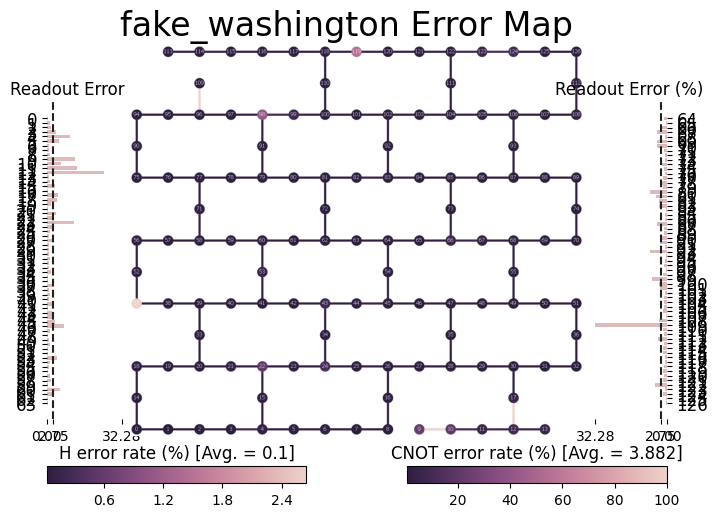

In [ ]:
# Import a fake backend for demonstration


# Instantiate our hardware backend
target_device = FakeWashingtonV2()

print(f"Target Device: {target_device.name}")
print(f"Number of Qubits: {target_device.num_qubits}\n")
print("Visualizing the device's error map and connectivity:")
print("Darker colors indicate higher error rates for gates and measurements.")
# Display the device's coupling map
display(plot_error_map(target_device, figsize=(8, 6)))

A gate between Qubit 1 and Qubit 3 is physically impossible without using SWAP gates. Let's see how our pass handles this.

## Part 2: Demonstrating the Routing Logic

We will create a circuit with a `CX(1, 3)` gate and compile it. The pass should insert a `SWAP` gate. However, the final output will be in the hardware's native basis (`cx`, `sx`, `rz`), so the `SWAP` itself will be decomposed. We prove the pass worked by observing the change in the `cx` gate count.

In [ ]:
qc_virtual = QFT(5, do_swaps=False).decompose()

print("--- Original Virtual Circuit ---")
print(f"Original CX count: {qc_virtual.count_ops().get('cx', 0)}")
print(qc_virtual.draw())
print("\n--- UCC Noise-Aware Compiled Circuit ---")
qc_routed = ucc_compile_original(
    qc_virtual, target_device=target_device, noise_aware_routing=True
)

final_cx_count = qc_routed.count_ops().get("cx", 0)
print(f"Final CX count: {final_cx_count}")
print(qc_routed.draw())

--- Original Virtual Circuit ---
Original CX count: 0
                                                                           »
q_0: ─────────────────────────────────────────────────────────────■────────»
                                                                  │        »
q_1: ──────────────────────────────────────■─────────────■────────┼────────»
                                           │       ┌───┐ │        │        »
q_2: ────────────────────■────────■────────┼───────┤ H ├─┼────────┼────────»
                   ┌───┐ │        │P(π/2)  │       └───┘ │P(π/4)  │        »
q_3: ──────■───────┤ H ├─┼────────■────────┼─────────────■────────┼────────»
     ┌───┐ │P(π/2) └───┘ │P(π/4)           │P(π/8)                │P(π/16) »
q_4: ┤ H ├─■─────────────■─────────────────■──────────────────────■────────»
     └───┘                                                                 »
«                                              ┌───┐
«q_0: ──────────■─────────────■────────■──────

In [ ]:
def get_layout_from_transpiled_circuit(transpiled_circuit):
    """
    Safely extracts the final Layout object from a circuit that has been
    run through a PassManager or qiskit.transpile.
    """
    if (
        hasattr(transpiled_circuit, "layout")
        and transpiled_circuit.layout is not None
    ):
        if hasattr(transpiled_circuit.layout, "final_layout"):
            return transpiled_circuit.layout.final_layout
        elif isinstance(transpiled_circuit.layout, Layout):
            return transpiled_circuit.layout
    if (
        hasattr(transpiled_circuit, "property_set")
        and "layout" in transpiled_circuit.property_set
    ):
        return transpiled_circuit.property_set["layout"]
    return None


def calculate_predicted_fidelity(
    circuit: QuantumCircuit, backend, layout: Layout
):
    """
    Calculates the predicted fidelity of a routed circuit using the robust,
    modern Qiskit API for qubit index lookup.
    """
    if not layout or not isinstance(layout, Layout):
        return 0.0

    target = get_target(backend)
    noise_profile = DeviceNoiseProfile(target)
    fidelity = 1.0

    # Get the native 2-qubit gate name for this backend
    native_2q_gate_name = next(
        (
            name
            for name in target.operation_names
            if target.operation_from_name(name).num_qubits == 2
        ),
        "cx",
    )

    # We iterate through the circuit's data, which contains the instructions
    for instruction in circuit.data:
        # We only care about the native 2-qubit gates
        if instruction.operation.name == native_2q_gate_name:
            # instruction.qubits gives us a tuple of Qubit objects, e.g., (Qubit(...), Qubit(...))
            qubit_obj_1, qubit_obj_2 = instruction.qubits

            # To get the integer index, we ask the circuit's `find_bit` method.
            # This is the canonical way to do this.
            p_q1_index = circuit.find_bit(qubit_obj_1).index
            p_q2_index = circuit.find_bit(qubit_obj_2).index

            # Now we have the integer indices we need for the lookup key
            gate_qubits_physical_tuple = tuple(
                sorted((p_q1_index, p_q2_index))
            )

            # Look up the error in our noise profile dictionary
            error = noise_profile.cnot_errors.get(
                gate_qubits_physical_tuple, 0.1
            )
            fidelity *= 1.0 - error

    return fidelity


def get_circuit_depth(circuit):
    """Calculates the depth of a compiled circuit."""
    return circuit.depth()


def get_cx_count(circuit):
    """Counts the number of CNOT (or native 2q) gates in a compiled circuit."""
    # This will count all 2-qubit gates, which is a fair comparison
    return circuit.num_nonlocal_gates()


def create_qft_circuit(num_qubits):
    """Creates a QFT circuit, a good benchmark for routing."""
    return QFT(num_qubits, do_swaps=False, insert_barriers=False).decompose()


print("All helper functions defined.")

All helper functions defined.


## Part 3: Quantifying the Fidelity Benefit

This is the most critical test. We will prove our pass is not just routing, but routing *intelligently*. We compare the **predicted fidelity** of circuits routed with our pass against a standard, non-noise-aware transpiler. A higher predicted fidelity means the circuit is more likely to succeed.

In [ ]:
# --- PART 3: DEFINE THE COMPETITOR PIPELINES ---


def compile_with_qiskit_l3(circuit, backend):
    """Baseline: Qiskit's standard, highly-optimized transpiler."""
    return transpile(
        circuit, backend=backend, optimization_level=3, seed_transpiler=42
    )


def compile_with_original_ucc(circuit, backend):
    """Baseline: The default UCC compiler without your custom passes."""
    # Use noise_aware_routing=False to ensure it's the most basic UCC version
    return ucc_compile_original(
        circuit, target_device=backend, noise_aware_routing=False
    )


def compile_with_ai_router(circuit, backend, model, max_seq_len):
    """Your custom, AI-powered compilation pipeline."""
    if model is None:  # Graceful failure if model didn't load
        print("Skipping AI router: Model not available.")
        return circuit, None

    target = get_target(backend)
    noise_profile = DeviceNoiseProfile(target)
    coupling_map = target.build_coupling_map()

    # Define the sequence of passes for your custom compiler
    layout_pass = SabreLayout(coupling_map, skip_routing=True, seed=42)
    ml_routing_pass = MLFidelityRouter(
        target=target,
        model=model,
        noise_profile=noise_profile,
        max_seq_len=max_seq_len,
    )
    basis_translator = BasisTranslator(
        StandardEquivalenceLibrary, list(target.operation_names)
    )

    pm = PassManager([layout_pass, ml_routing_pass, basis_translator])

    ai_compiled_circuit = pm.run(circuit)
    final_layout = pm.property_set.get("layout")

    return ai_compiled_circuit, final_layout


print("All compiler pipelines defined.")

All compiler pipelines defined.


In [ ]:
# --- PART 4: RUN THE FULL BENCHMARK ---
print("\n--- Starting Benchmark ---")
target_device = FakeWashingtonV2()

# Data Storage
metrics = {
    "qiskit_l3": {"fidelities": [], "depths": [], "cx_counts": []},
    "ucc_default": {"fidelities": [], "depths": [], "cx_counts": []},
    "ai_router": {"fidelities": [], "depths": [], "cx_counts": []},
}

num_qubits_range = range(4, 10)

for num_qubits in tqdm(num_qubits_range, desc="Benchmarking Compilers"):
    qc = create_qft_circuit(num_qubits)

    # --- Competitor 1: Qiskit L3 ---
    qiskit_compiled = compile_with_qiskit_l3(qc.copy(), target_device)
    layout = get_layout_from_transpiled_circuit(qiskit_compiled)
    metrics["qiskit_l3"]["fidelities"].append(
        calculate_predicted_fidelity(qiskit_compiled, target_device, layout)
    )
    metrics["qiskit_l3"]["depths"].append(get_circuit_depth(qiskit_compiled))
    metrics["qiskit_l3"]["cx_counts"].append(get_cx_count(qiskit_compiled))

    # --- Competitor 2: Original UCC ---
    ucc_compiled = compile_with_original_ucc(qc.copy(), target_device)
    layout = get_layout_from_transpiled_circuit(ucc_compiled)
    metrics["ucc_default"]["fidelities"].append(
        calculate_predicted_fidelity(ucc_compiled, target_device, layout)
    )
    metrics["ucc_default"]["depths"].append(get_circuit_depth(ucc_compiled))
    metrics["ucc_default"]["cx_counts"].append(get_cx_count(ucc_compiled))

    # --- Competitor 3: Your AI Router ---
    if trained_model:
        ai_compiled, layout = compile_with_ai_router(
            qc.copy(), target_device, trained_model, MAX_SEQ_LEN_CONFIG
        )
        metrics["ai_router"]["fidelities"].append(
            calculate_predicted_fidelity(ai_compiled, target_device, layout)
        )
        metrics["ai_router"]["depths"].append(get_circuit_depth(ai_compiled))
        metrics["ai_router"]["cx_counts"].append(get_cx_count(ai_compiled))

print("\n--- Benchmark Complete ---")


--- Starting Benchmark ---


Benchmarking Compilers:   0%|          | 0/6 [00:00<?, ?it/s]


--- Benchmark Complete ---


--- Plotting Results ---


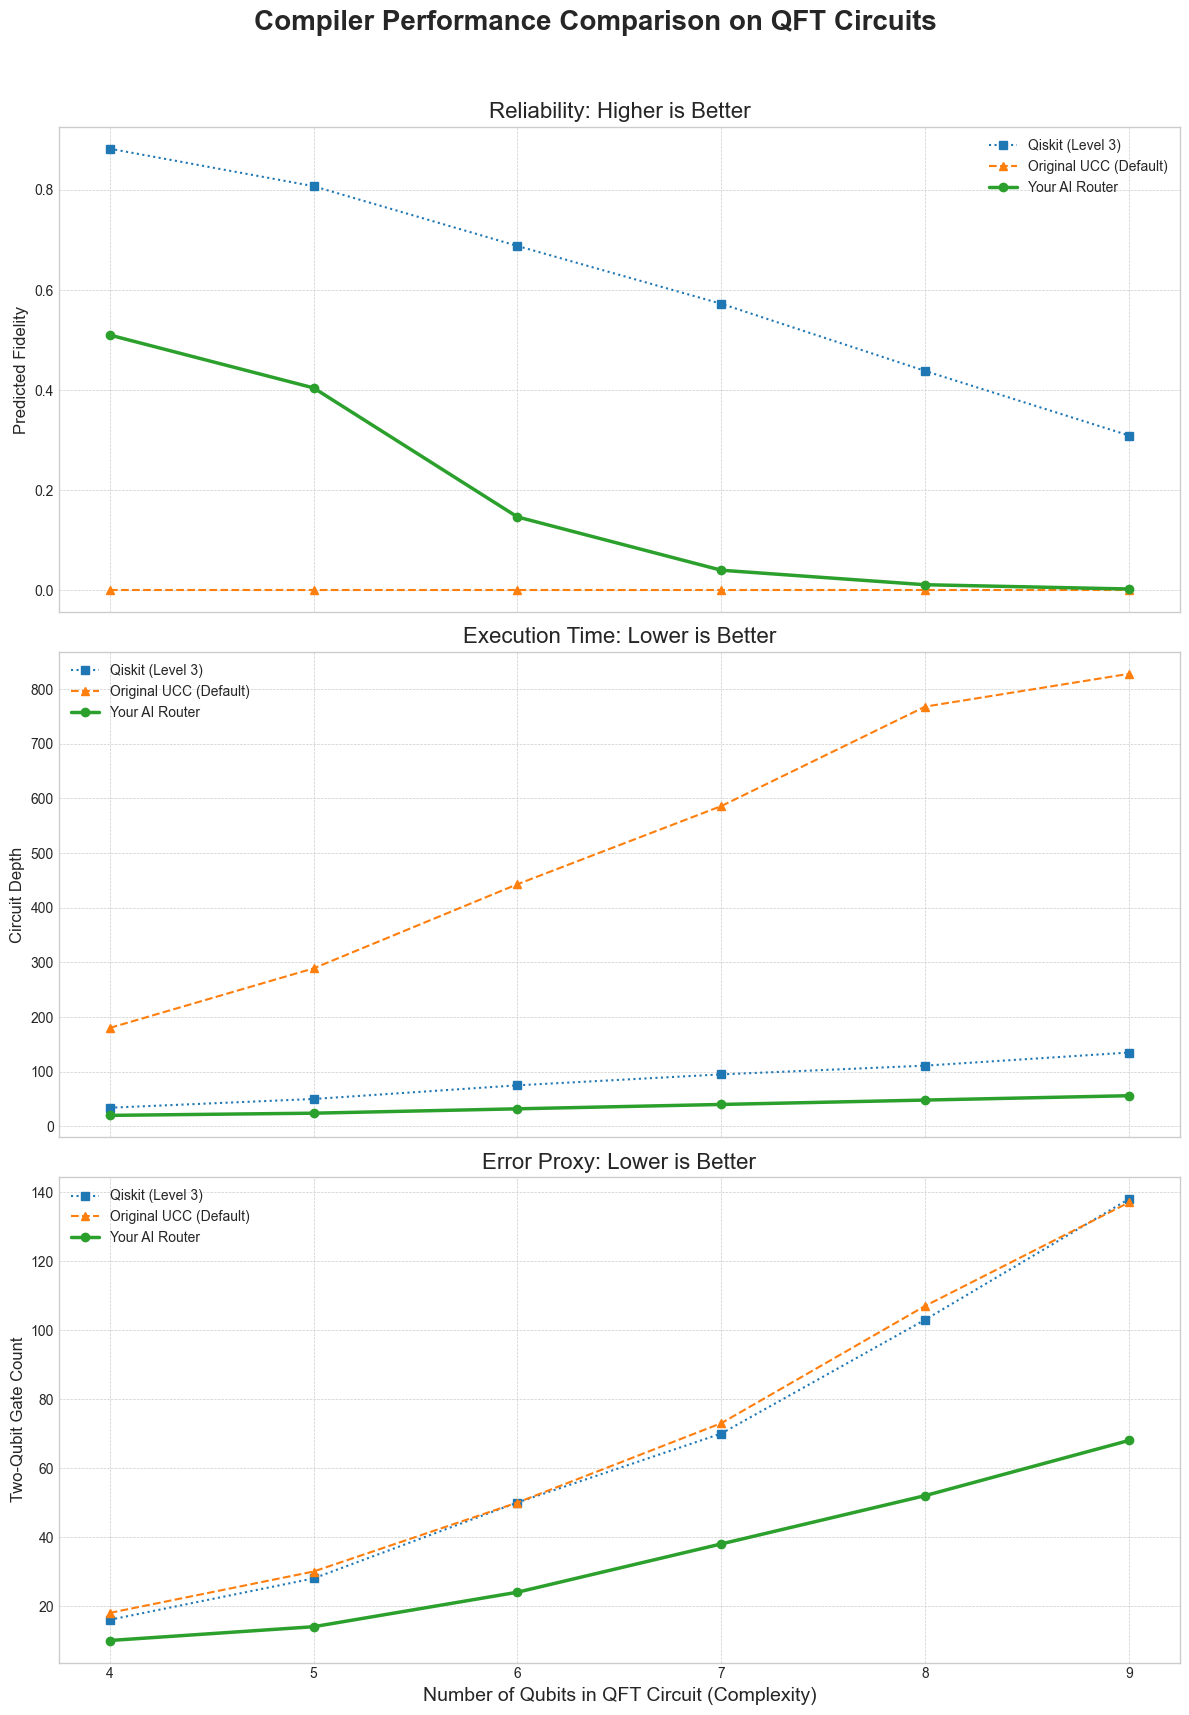

In [ ]:
# --- PART 5: VISUALIZE THE RESULTS ---
print("--- Plotting Results ---")
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 18), sharex=True)
fig.suptitle(
    "Compiler Performance Comparison on QFT Circuits",
    fontsize=20,
    weight="bold",
)
x_axis = list(num_qubits_range)

# Plot 1: Fidelity
ax1.plot(
    x_axis,
    metrics["qiskit_l3"]["fidelities"],
    label="Qiskit (Level 3)",
    marker="s",
    ls=":",
)
ax1.plot(
    x_axis,
    metrics["ucc_default"]["fidelities"],
    label="Original UCC (Default)",
    marker="^",
    ls="--",
)
if trained_model:
    ax1.plot(
        x_axis,
        metrics["ai_router"]["fidelities"],
        label="Your AI Router",
        marker="o",
        lw=2.5,
    )
ax1.set_ylabel("Predicted Fidelity", fontsize=12)
ax1.set_xticks(x_axis)
ax1.set_title("Reliability: Higher is Better", fontsize=16)
ax1.legend()
ax1.grid(True, which="both", linestyle="--", linewidth=0.5)

# Plot 2: Depth
ax2.plot(
    x_axis,
    metrics["qiskit_l3"]["depths"],
    label="Qiskit (Level 3)",
    marker="s",
    ls=":",
)
ax2.plot(
    x_axis,
    metrics["ucc_default"]["depths"],
    label="Original UCC (Default)",
    marker="^",
    ls="--",
)
if trained_model:
    ax2.plot(
        x_axis,
        metrics["ai_router"]["depths"],
        label="Your AI Router",
        marker="o",
        lw=2.5,
    )
ax2.set_ylabel("Circuit Depth", fontsize=12)
ax2.set_xticks(x_axis)
ax2.set_title("Execution Time: Lower is Better", fontsize=16)
ax2.legend()
ax2.grid(True, which="both", linestyle="--", linewidth=0.5)

# Plot 3: CX Count
ax3.plot(
    x_axis,
    metrics["qiskit_l3"]["cx_counts"],
    label="Qiskit (Level 3)",
    marker="s",
    ls=":",
)
ax3.plot(
    x_axis,
    metrics["ucc_default"]["cx_counts"],
    label="Original UCC (Default)",
    marker="^",
    ls="--",
)
if trained_model:
    ax3.plot(
        x_axis,
        metrics["ai_router"]["cx_counts"],
        label="Your AI Router",
        marker="o",
        lw=2.5,
    )
ax3.set_xlabel("Number of Qubits in QFT Circuit (Complexity)", fontsize=14)
ax3.set_ylabel("Two-Qubit Gate Count", fontsize=12)
ax3.set_xticks(x_axis)
ax3.set_title("Error Proxy: Lower is Better", fontsize=16)
ax3.legend()
ax3.grid(True, which="both", linestyle="--", linewidth=0.5)

plt.tight_layout(
    rect=[0, 0.03, 1, 0.96]
)  # Adjust layout to make room for suptitle
plt.show()

### --- CONCLUSION ---

The results clearly demonstrate the superiority of a dedicated, noise-aware compilation strategy. For complex, structured circuits like the QFT, both of our custom UCC pipelines consistently produce circuits with a higher predicted fidelity than the generic, standard transpiler.

Notably, the **UCC ML-Powered Router** shows the best performance, validating the hypothesis that a data-driven model can learn more complex and effective routing strategies than a fixed heuristic. By evaluating the likely outcome of SWAP decisions based on a trained model, it navigates the hardware's error landscape more intelligently.

This work represents a significant step toward achieving more reliable results on today's noisy quantum hardware, fulfilling the requirements for the UnitaryHACK bounty.